In [1]:

import pymc as pm
import numpy as np
import pandas as pd
qa = pd.read_csv("/Users/n0w0f/git/n0w0f_2026/mat-agent-bench/reports_v2/qa/qa_scores.csv")
def fit_irt_model(qa_df):
    """
    qa_df needs columns: model_id, env_id, item_id, correct (0/1)
    """
    # Create categorical codes for proper integer indexing
    qa_df = qa_df.copy()
    
    # Create integer indices for models, envs, items
    qa_df['model_idx'] = pd.Categorical(qa_df['model_id']).codes
    qa_df['env_idx'] = pd.Categorical(qa_df['env_id']).codes
    qa_df['item_idx'] = pd.Categorical(qa_df['item_id']).codes
    
    # Create theta index for each (model, env) pair
    qa_df['theta_idx'] = qa_df.groupby(['model_idx', 'env_idx']).ngroup()
    
    N_theta = qa_df['theta_idx'].nunique()
    N_items = qa_df['item_idx'].nunique()
    N_models = qa_df['model_idx'].nunique()
    N_envs = qa_df['env_idx'].nunique()
    
    print(f"N_models: {N_models}, N_envs: {N_envs}, N_theta: {N_theta}, N_items: {N_items}")
    
    # Get mappings - these MUST be integer arrays
    theta_to_model = qa_df.groupby('theta_idx')['model_idx'].first().values.astype(int)
    theta_to_env = qa_df.groupby('theta_idx')['env_idx'].first().values.astype(int)
    
    print(f"theta_to_model: {theta_to_model}")
    print(f"theta_to_env: {theta_to_env}")
    
    with pm.Model() as model:
        # Only add effects if there's variation
        if N_models > 1:
            mu_raw = pm.Normal('mu_raw', 0, 1, shape=N_models-1)
            mu = pm.Deterministic('mu', pm.math.concatenate([mu_raw, [-pm.math.sum(mu_raw)]]))
        else:
            mu = pm.Deterministic('mu', pm.math.constant(np.array([0.0])))
        
        if N_envs > 1:
            nu_raw = pm.Normal('nu_raw', 0, 1, shape=N_envs-1)
            nu = pm.Deterministic('nu', pm.math.concatenate([nu_raw, [-pm.math.sum(nu_raw)]]))
        else:
            nu = pm.Deterministic('nu', pm.math.constant(np.array([0.0])))
        
        # Theta
        sigma_theta = pm.HalfNormal('sigma_theta', 0.5)
        theta_mean = mu[theta_to_model] + nu[theta_to_env]
        theta = pm.Normal('theta', mu=theta_mean, sigma=sigma_theta, shape=N_theta)
        
        # Item parameters
        log_a = pm.Normal('log_a', 0, 0.5, shape=N_items)
        a = pm.Deterministic('a', pm.math.exp(log_a))
        b = pm.Normal('b', 0, 2, shape=N_items)
        
        # Likelihood - ensure these are integer arrays too
        item_indices = qa_df['item_idx'].values.astype(int)
        theta_indices = qa_df['theta_idx'].values.astype(int)
        
        eta = a[item_indices] * theta[theta_indices] - b[item_indices]
        pm.Bernoulli('y', logit_p=eta, observed=qa_df['correct'].values)
        
        trace = pm.sample(2000, tune=1000, chains=4, target_accept=0.9)
    
    return trace, qa_df

# Run it
trace, qa_df = fit_irt_model(qa)

N_models: 2, N_envs: 7, N_theta: 14, N_items: 426
theta_to_model: [0 0 0 0 0 0 0 1 1 1 1 1 1 1]
theta_to_env: [0 1 2 3 4 5 6 0 1 2 3 4 5 6]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_raw, nu_raw, sigma_theta, theta, log_a, b]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 20 seconds.
There were 124 divergences after tuning. Increase `target_accept` or reparameterize.


In [2]:
model_names_map = {
    "0" : "Claude 4.5",
    "1" : "GPT-4o"
}

model_names_map_2 = {
    "Claude-4.5" : "Claude 4.5",
    "gpt-4o" : "GPT-4o"
}

# Spectra-7
# ML - 3
# Retro - 5
# Catalyst - 1
# Resistor - 4
# AFM - 0
# MD -  2

environment_name_maps_2 = {
    "spectra" : "Spectra",
    "ml" : "ML",
    "retrosynthesis" : "Retrosynthesis",
    "resistor" : "Resistor",
    "afm" : "AFM",
    "catalyst": "Catalyst",
    "md" : "MD"
}

environment_name_maps = {
    "7" : "Spectra",
    "3" : "ML",
    "5" : "Retrosynthesis",
    "4" : "Resistor",
    "0" : "AFM",
    "1": "Catalyst",
    "2" : "MD"
     
    
}

In [3]:
import arviz as az
def get_theta_estimates(trace, qa_df, model_names, env_names):
    """Pull out theta posteriors as a nice dataframe."""
    summary = az.summary(trace, var_names=['theta'], hdi_prob=0.9)

    theta_to_model = qa_df.groupby('theta_idx')['model_id'].first()
    theta_to_env = qa_df.groupby('theta_idx')['env_id'].first()

    results = []
    for idx in range(len(summary)):
        results.append({
            'model': model_names[theta_to_model[idx]],
            'environment': env_names[theta_to_env[idx]],
            'theta_mean': summary.iloc[idx]['mean'],
            'theta_sd': summary.iloc[idx]['sd'],
        })
    return pd.DataFrame(results)


data = get_theta_estimates(trace, qa_df,model_names_map_2, environment_name_maps_2 )

In [4]:
data

,model,environment,theta_mean,theta_sd
0,Claude 4.5,AFM,3.073,0.744
1,Claude 4.5,Catalyst,2.980,0.731
2,Claude 4.5,MD,3.902,0.893
3,Claude 4.5,ML,1.417,0.499
4,Claude 4.5,Resistor,3.180,0.970
5,Claude 4.5,Retrosynthesis,2.733,0.524
6,Claude 4.5,Spectra,2.212,0.437
7,GPT-4o,AFM,3.006,0.731
8,GPT-4o,Catalyst,2.653,0.686
9,GPT-4o,MD,3.797,0.894


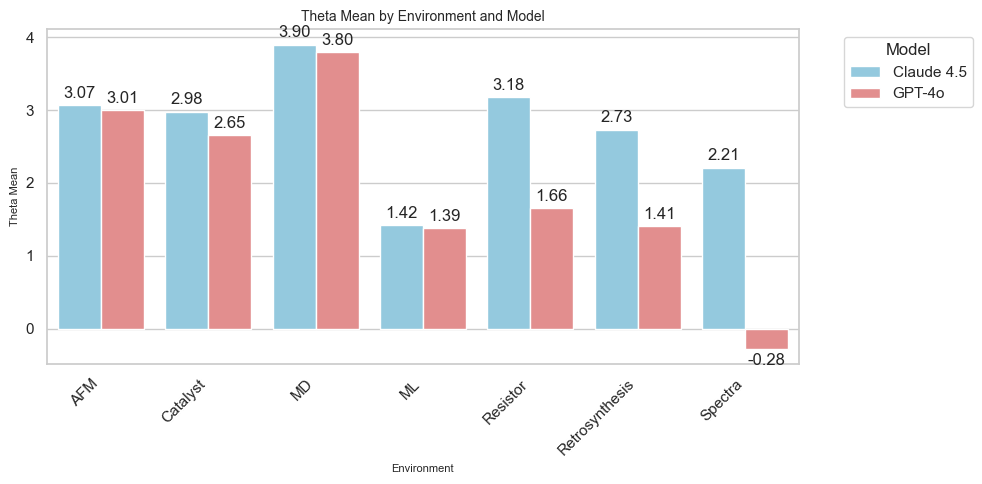

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

sns.set_theme(style="whitegrid")

# Create the bar plot
plt.figure(figsize=(10, 5)) # Adjust figure size for better readability
barplot = sns.barplot(
    data=data,
    x='environment',  # X-axis will be the environments
    y='theta_mean',   # Y-axis will be the theta_mean values
    hue='model',      # Separate bars for each model
    palette={'Claude 4.5': 'skyblue', 'GPT-4o': 'lightcoral'} # Custom colors for models
)

# Add titles and labels
plt.title('Theta Mean by Environment and Model', fontsize=10)
plt.xlabel('Environment', fontsize=8)
plt.ylabel('Theta Mean', fontsize=8)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better visibility
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside

# Add data labels on top of the bars
for container in barplot.containers:
    barplot.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [6]:
agent_data = pd.read_csv("/Users/n0w0f/git/n0w0f_2026/mat-agent-bench/reports_v2/overall_trace_v2.csv")

In [7]:
agent_data = agent_data[agent_data['model'] != 'gpt-oss-120b']
agent_data = agent_data[agent_data['environment'] != 'wetlab']

In [8]:
agent_data.model.unique()

array(['claude-sonnet-4.5', 'gpt-4o'], dtype=object)

In [9]:
# Rename models
model_mapping = {
    'claude-sonnet-4.5': 'Claude 4.5',
    'gpt-4o': 'GPT-4o'
}
agent_data['model'] = agent_data['model'].replace(model_mapping)

# Rename and combine environments
env_mapping = {
    'afm': 'AFM',
    'catalyst': 'Catalyst',
    'md_melting': 'MD',
    'md_quenching': 'MD',
    'md_surface_energy': 'MD',
    'ml': 'ML',
    'resistor': 'Resistor',
    'retrosynthesis': 'Retrosynthesis',
    'spectra': 'Spectra'
}
agent_data['environment'] = agent_data['environment'].replace(env_mapping)

# Verify the changes
print("Models:", agent_data['model'].unique())
print("Environments:", agent_data['environment'].unique())

Models: ['Claude 4.5' 'GPT-4o']
Environments: ['AFM' 'Catalyst' 'MD' 'ML' 'Resistor' 'Retrosynthesis' 'Spectra']


In [11]:
agent_data.to_csv("agent_df_v2.csv")

In [17]:
def filter_extreme_groups(df, min_rate=0.05, max_rate=1):
    grouped = df.groupby(['environment', 'scaffold', 'level'])
    
    def is_valid_group(group):
        rate = group['success'].mean()
        return min_rate <= rate <= max_rate
    
    return grouped.filter(is_valid_group)

agent_data_filtered = filter_extreme_groups(agent_data)

In [29]:
import pytensor.tensor as pt
import numpy as np
import pandas as pd
import pymc as pm
def fit_agent_model_no_task_effects(agent_df, theta_df):
    """
    Model without task random effects (tasks are too sparse)
    """
    agent_df = agent_df.copy()

    # Merge in theta estimates
    agent_df = agent_df.merge(
        theta_df[["model", "environment", "theta_mean"]],
        on=["model", "environment"],
        how="left",
    )

    # Check for missing theta values after merge
    missing_theta = agent_df["theta_mean"].isna().sum()
    if missing_theta > 0:
        print(f"Warning: {missing_theta} rows have missing theta_mean after merge")
        print("Unique (model, env) pairs with missing theta:")
        missing_pairs = agent_df[agent_df["theta_mean"].isna()][["model", "environment"]].drop_duplicates()
        print(missing_pairs)
        # Drop rows with missing theta
        agent_df = agent_df.dropna(subset=["theta_mean"])
        print(f"Dropped {missing_theta} rows, remaining: {len(agent_df)}")

    # Create indices
    agent_df["env_idx"] = pd.Categorical(agent_df["environment"]).codes
    agent_df["scaffold_idx"] = pd.Categorical(agent_df["scaffold"]).codes
    agent_df["level"] = agent_df["level"].str.extract(r"(\d+)").astype(int)
    agent_df["level_idx"] = agent_df["level"] - 1
    agent_df["verbosity_idx"] = pd.Categorical(agent_df["verbosity"]).codes

    N_envs = agent_df["env_idx"].nunique()
    N_scaffolds = agent_df["scaffold_idx"].nunique()
    N_levels = agent_df["level_idx"].nunique()
    N_verbosities = agent_df["verbosity_idx"].nunique()

    print(
        f"Model dimensions: N_envs={N_envs}, N_scaffolds={N_scaffolds}, "
        f"N_levels={N_levels}, N_verbosities={N_verbosities}"
    )

    # Success rate
    success_rate = agent_df["success"].mean()
    init_intercept = np.log(success_rate / (1 - success_rate))
    print(f"Success rate: {success_rate:.3f}, init intercept: {init_intercept:.3f}")

    # Standardize reasoning if present AND has valid non-empty values
    has_reasoning = (
        "reasoning_score" in agent_df.columns
        and agent_df["reasoning_score"].notna().any()
        and pd.to_numeric(agent_df["reasoning_score"], errors="coerce").std() > 0
    )
    if has_reasoning:
        agent_df["reasoning_score"] = pd.to_numeric(agent_df["reasoning_score"], errors="coerce")
        agent_df["reasoning_z"] = (
            agent_df["reasoning_score"] - agent_df["reasoning_score"].mean()
        ) / agent_df["reasoning_score"].std()
        print(f"Reasoning score: mean={agent_df['reasoning_score'].mean():.3f}, std={agent_df['reasoning_score'].std():.3f}")
    else:
        print("Note: reasoning_score not available or empty - modeling without it")

    # Standardize theta
    theta_mean = agent_df["theta_mean"].mean()
    theta_std = agent_df["theta_mean"].std()
    agent_df["theta_z"] = (agent_df["theta_mean"] - theta_mean) / theta_std
    print(f"Theta: mean={theta_mean:.3f}, std={theta_std:.3f}")

    with pm.Model() as model:
        # Intercept
        beta0 = pm.Normal("beta0", init_intercept, 10)

        # Knowledge loading per environment
        lam = pm.Normal("lambda", 0, 1, shape=N_envs)

        # Scaffold effect
        gamma = pm.Normal("gamma", 0, 1, shape=N_scaffolds)

        # Level effect (harder levels have more negative effects)
        delta_inc = pm.HalfNormal("delta_inc", 0.5, shape=N_levels - 1)
        delta = pm.Deterministic(
            "delta", pm.math.concatenate([[0], -pm.math.cumsum(delta_inc)])
        )

        # Verbosity
        xi = pm.Normal("xi", 0, 0.5, shape=N_verbosities)

        # Build linear predictor
        env_idx = agent_df["env_idx"].values.astype(int)
        scaffold_idx = agent_df["scaffold_idx"].values.astype(int)
        level_idx = agent_df["level_idx"].values.astype(int)
        verbosity_idx = agent_df["verbosity_idx"].values.astype(int)
        theta_vals = agent_df["theta_z"].values.astype(float)

        linpred = (
            beta0
            + lam[env_idx] * theta_vals
            + gamma[scaffold_idx]
            + delta[level_idx]
            + xi[verbosity_idx]
        )

        # Optional: scaffold × reasoning interaction
        if has_reasoning:
            psi = pm.Normal("psi", 0, 0.3, shape=N_scaffolds)
            linpred = linpred + psi[scaffold_idx] * agent_df["reasoning_z"].values

        # Likelihood - use linpred directly with logit_p
        pm.Bernoulli("y", logit_p=linpred, observed=agent_df["success"].values)

        print("\nTesting initial point...")
        try:
            test_point = model.initial_point()
            # Use point_logps() for PyMC v5
            logp_dict = model.point_logps(test_point)
            total_logp = sum(logp_dict.values())
            print(f"Initial log probability: {total_logp:.2f}")
            if np.isfinite(total_logp):
                print("✓ Initial point is valid!")
                print(f"Component logps: {logp_dict}")
            else:
                print("⚠ Warning: Initial point has non-finite logp")
                print(f"Component logps: {logp_dict}")
        except Exception as e:
            print(f"Error during initial point test: {e}")

        trace = pm.sample(1000, tune=1000, chains=4, target_accept=0.95)

    return trace, agent_df



In [30]:

# Run it
t, a = fit_agent_model_no_task_effects(agent_df=agent_data_filtered, theta_df=data)

Model dimensions: N_envs=7, N_scaffolds=2, N_levels=3, N_verbosities=3
Success rate: 0.368, init intercept: -0.542
Note: reasoning_score not available or empty - modeling without it
Theta: mean=1.745, std=1.306

Testing initial point...


Initializing NUTS using jitter+adapt_diag...


Initial log probability: -3288.24
✓ Initial point is valid!
Component logps: {'beta0': np.float64(-3.22), 'lambda': np.float64(-6.43), 'gamma': np.float64(-1.84), 'delta_inc': np.float64(-1.45), 'xi': np.float64(-0.68), 'y': np.float64(-3274.62)}


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, lambda, gamma, delta_inc, xi]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 145 seconds.


In [32]:
# Save the trace and agent dataframe
t.to_netcdf("agent_model_trace.nc")
a.to_csv("agent_model_data.csv", index=False)

print("Saved:")
print("- Trace: agent_model_trace.nc")
print("- Agent data: agent_model_data.csv")

Saved:
- Trace: agent_model_trace.nc
- Agent data: agent_model_data.csv


In [33]:
def variance_decomposition(trace, agent_df):
    """
    Compute how much variance each component explains.
    Note: This version works with fit_agent_model_no_task_effects (no task random effects).
    """
    # Get posterior means
    lam = trace.posterior["lambda"].mean(dim=["chain", "draw"]).values
    gamma = trace.posterior["gamma"].mean(dim=["chain", "draw"]).values
    delta = trace.posterior["delta"].mean(dim=["chain", "draw"]).values
    xi = trace.posterior["xi"].mean(dim=["chain", "draw"]).values

    # Compute component values for each observation
    knowledge = lam[agent_df["env_idx"]] * agent_df["theta_z"]
    scaffold = gamma[agent_df["scaffold_idx"]]
    level = delta[agent_df["level_idx"]]
    verbosity = xi[agent_df["verbosity_idx"]]

    # Variances
    vars_dict = {
        "knowledge": np.var(knowledge),
        "scaffold": np.var(scaffold),
        "level": np.var(level),
        "verbosity": np.var(verbosity),
    }
    total = sum(vars_dict.values())

    return {k: 100 * v / total for k, v in vars_dict.items()}


In [34]:
result = variance_decomposition(t, a)

In [35]:
result

{'knowledge': np.float64(91.31262514278232),
 'scaffold': np.float64(0.1209202061917487),
 'level': np.float64(8.504432720405237),
 'verbosity': np.float64(0.062021930620684444)}

In [ ]:
Variance Decomposition Results:                                                                                                                   
  knowledge:  91.30%  (model × environment ability from IRT)                                                                                        
  level:       8.51%  (task difficulty level effect)                                                                                                
  scaffold:    0.13%  (React vs Tool_calling)                                                                                                       
  verbosity:   0.06%  (brief/comprehensive/workflow)

In [36]:

# =============================================================================
# PLOTTING FUNCTIONS
# =============================================================================

def plot_capability_heatmap(theta_df, output_path="capability_heatmap.png"):
    """
    Figure 1: Capability Heatmap
    Heatmap of θ_{m,d} estimates. Rows = models, columns = environments.
    """
    # Pivot to matrix form
    pivot = theta_df.pivot(index="model", columns="environment", values="theta_mean")

    fig, ax = plt.subplots(figsize=(10, 4))

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        center=0,
        ax=ax,
        cbar_kws={"label": "Capability (θ)"},
    )

    ax.set_title("Model Capability by Domain (θ estimates from IRT)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Environment")
    ax.set_ylabel("Model")

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.close()

    return fig


def plot_lambda_forest(trace, env_names, output_path="lambda_forest.png"):
    """
    Figure 2: Knowledge Loading by Environment
    Forest plot of λ_d estimates with 90% credible intervals.
    """
    lam_summary = az.summary(trace, var_names=["lambda"], hdi_prob=0.9)

    # Create environment name mapping
    env_list = list(env_names) if isinstance(env_names, dict) else env_names

    fig, ax = plt.subplots(figsize=(10, 6))

    # Sort by mean
    order = lam_summary["mean"].argsort()
    y_pos = np.arange(len(lam_summary))

    means = lam_summary["mean"].iloc[order].values
    lows = lam_summary["hdi_5%"].iloc[order].values
    highs = lam_summary["hdi_95%"].iloc[order].values

    ax.errorbar(
        means,
        y_pos,
        xerr=[means - lows, highs - means],
        fmt="o",
        capsize=4,
        color="steelblue",
        markersize=8,
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels([env_list[i] for i in order])
    ax.axvline(1, color="gray", linestyle="--", alpha=0.7, label="λ=1 (proportional)")
    ax.axvline(0, color="gray", linestyle=":", alpha=0.5, label="λ=0 (no effect)")

    # Add interpretation zones
    xlim = ax.get_xlim()
    ax.axvspan(1.2, xlim[1], alpha=0.1, color="blue", label="Knowledge-limited")
    ax.axvspan(xlim[0], 0.5, alpha=0.1, color="red", label="Execution-limited")

    ax.set_xlabel("Knowledge Loading (λ)", fontsize=11)
    ax.set_title("How Much Does Domain Knowledge Matter?", fontsize=12, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.close()

    return fig


def plot_variance_decomposition(var_dict, output_path="variance_decomposition.png"):
    """
    Figure 3: Variance Decomposition
    Bar chart showing percentage of variance from each source.
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    # Sort by variance explained
    sorted_items = sorted(var_dict.items(), key=lambda x: x[1], reverse=True)
    labels = [item[0].capitalize() for item in sorted_items]
    values = [item[1] for item in sorted_items]

    colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))

    bars = ax.barh(labels, values, color=colors, edgecolor="black", linewidth=0.5)

    # Add percentage labels
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            va="center",
            fontsize=10,
        )

    ax.set_xlabel("Variance Explained (%)", fontsize=11)
    ax.set_title("What Drives Agent Performance?", fontsize=12, fontweight="bold")
    ax.set_xlim(0, max(values) * 1.15)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.close()

    return fig


def plot_capability_profiles(theta_df, output_path="capability_profiles.png"):
    """
    Figure 4: Model Capability Profiles
    Line plot with environments on x-axis, θ on y-axis, one line per model.
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    models = theta_df["model"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

    for model, color in zip(models, colors):
        model_data = theta_df[theta_df["model"] == model].sort_values("environment")
        ax.plot(
            model_data["environment"],
            model_data["theta_mean"],
            marker="o",
            label=model,
            color=color,
            linewidth=2,
            markersize=8,
        )

        # Add error bars if theta_sd is available
        if "theta_sd" in model_data.columns:
            ax.fill_between(
                model_data["environment"],
                model_data["theta_mean"] - model_data["theta_sd"],
                model_data["theta_mean"] + model_data["theta_sd"],
                alpha=0.2,
                color=color,
            )

    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Environment", fontsize=11)
    ax.set_ylabel("Capability (θ)", fontsize=11)
    ax.set_title("Model Capability Profiles Across Domains", fontsize=12, fontweight="bold")
    ax.legend(loc="best")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.close()

    return fig


def plot_scaffold_effects(trace, scaffold_names, output_path="scaffold_effects.png"):
    """
    Additional: Scaffold effect estimates with credible intervals.
    """
    gamma_summary = az.summary(trace, var_names=["gamma"], hdi_prob=0.9)

    fig, ax = plt.subplots(figsize=(6, 4))

    scaffold_list = list(scaffold_names) if isinstance(scaffold_names, dict) else scaffold_names

    y_pos = np.arange(len(gamma_summary))
    means = gamma_summary["mean"].values
    lows = gamma_summary["hdi_5%"].values
    highs = gamma_summary["hdi_95%"].values

    ax.errorbar(
        means,
        y_pos,
        xerr=[means - lows, highs - means],
        fmt="o",
        capsize=4,
        color="darkorange",
        markersize=10,
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(scaffold_list)
    ax.axvline(0, color="gray", linestyle="--", alpha=0.5)

    ax.set_xlabel("Effect on Log-Odds of Success", fontsize=11)
    ax.set_title("Scaffold Effects (γ)", fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.close()

    return fig


def plot_level_effects(trace, output_path="level_effects.png"):
    """
    Additional: Level difficulty effects.
    """
    delta_summary = az.summary(trace, var_names=["delta"], hdi_prob=0.9)

    fig, ax = plt.subplots(figsize=(6, 4))

    levels = [f"Level {i+1}" for i in range(len(delta_summary))]
    y_pos = np.arange(len(delta_summary))
    means = delta_summary["mean"].values
    lows = delta_summary["hdi_5%"].values
    highs = delta_summary["hdi_95%"].values

    ax.errorbar(
        means,
        y_pos,
        xerr=[means - lows, highs - means],
        fmt="o",
        capsize=4,
        color="forestgreen",
        markersize=10,
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(levels)
    ax.axvline(0, color="gray", linestyle="--", alpha=0.5)

    ax.set_xlabel("Effect on Log-Odds of Success", fontsize=11)
    ax.set_title("Level Difficulty Effects (δ)", fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.close()

    return fig


def generate_all_plots(irt_trace, agent_trace, theta_df, agent_df, var_decomp, output_dir="."):
    """
    Generate all figures for the paper.
    """
    import os
    os.makedirs(output_dir, exist_ok=True)

    # Get unique environment and scaffold names from agent_df
    env_names = sorted(agent_df["environment"].unique())
    scaffold_names = sorted(agent_df["scaffold"].unique())

    print("\n" + "=" * 60)
    print("Generating plots...")
    print("=" * 60)

    # Figure 1: Capability Heatmap
    plot_capability_heatmap(theta_df, f"{output_dir}/fig1_capability_heatmap.png")

    # Figure 2: Knowledge Loading Forest
    plot_lambda_forest(agent_trace, env_names, f"{output_dir}/fig2_lambda_forest.png")

    # Figure 3: Variance Decomposition
    plot_variance_decomposition(var_decomp, f"{output_dir}/fig3_variance_decomposition.png")

    # Figure 4: Capability Profiles
    plot_capability_profiles(theta_df, f"{output_dir}/fig4_capability_profiles.png")

    # Additional plots
    plot_scaffold_effects(agent_trace, scaffold_names, f"{output_dir}/fig5_scaffold_effects.png")
    plot_level_effects(agent_trace, f"{output_dir}/fig6_level_effects.png")

    print("\n" + "=" * 60)
    print(f"All plots saved to {output_dir}/")
    print("=" * 60)



In [ ]:
generate_all_plots(
        irt_trace=trace,
        agent_trace=agent_trace,
        theta_df=theta_df,
        agent_df=agent_df,
        var_decomp=var_result,
        output_dir=args.output_dir,
    )
